## Task

A common task for cluster algorithms is image segmentation. In this example, a satellite image from the Landsat program is given. The image has a size of 1907 x 1784 pixels. Thus, with a resolution of 30 x 30 m per pixel, an area of about 57 x 53 km is covered. The recording system is able to cover the 6 bands of the electromagnetic spectrum (see figure). Try to determine individual landscape structures or vegetation areas by varying the number of clusters.

![Frequenzbänder](landsat.png)

In [1]:
import scipy.io as sio

data = sio.loadmat("DataSets/Colorado/sD_ZD10.mat")
satImg = data["sD_Colorado"]["data"][0][0]

In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [7]:
# ডেটা লোড করা
data = sio.loadmat("DataSets/Colorado/sD_ZD10.mat")
satImg = data["sD_Colorado"]["data"][0][0]

# প্রথমে প্রিন্ট করে দেখে নিই আসল শেইপ কী আছে
print("Actual shape:", satImg.shape)

# যদি আউটপুটে ২টি মান দেখায় (যেমন: পিক্সেল সংখ্যা, ব্যান্ড সংখ্যা)
# তাহলে সরাসরি নিচের কোডটি ব্যবহার করুন:
if len(satImg.shape) == 2:
    X = satImg  # অলরেডি ২D তে থাকলে আর reshape করার দরকার নেই
else:
    # যদি ৩টি মান থাকে, তবেই কেবল এভাবে রিসেপ হবে
    rows, cols, bands = satImg.shape
    X = satImg.reshape(rows * cols, bands)

Actual shape: (3402088, 6)


In [11]:
# ১. ক্লাস্টারের সংখ্যা নির্ধারণ (যেমন: ৩, ৪ বা ৫)
n_clusters = 4 

# ২. K-Means মডেল তৈরি এবং ফিট করা
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# ৩. টাস্কের বর্ণনা অনুযায়ী আসল ছবির সাইজ নির্ধারণ করা
rows = 1907
cols = 1784

# ৪. লেবেলগুলোকে আবার আসল ছবির আকারে (1907 × 1784) ফিরিয়ে আনা
segmented_img = labels.reshape(rows, cols)

/root/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


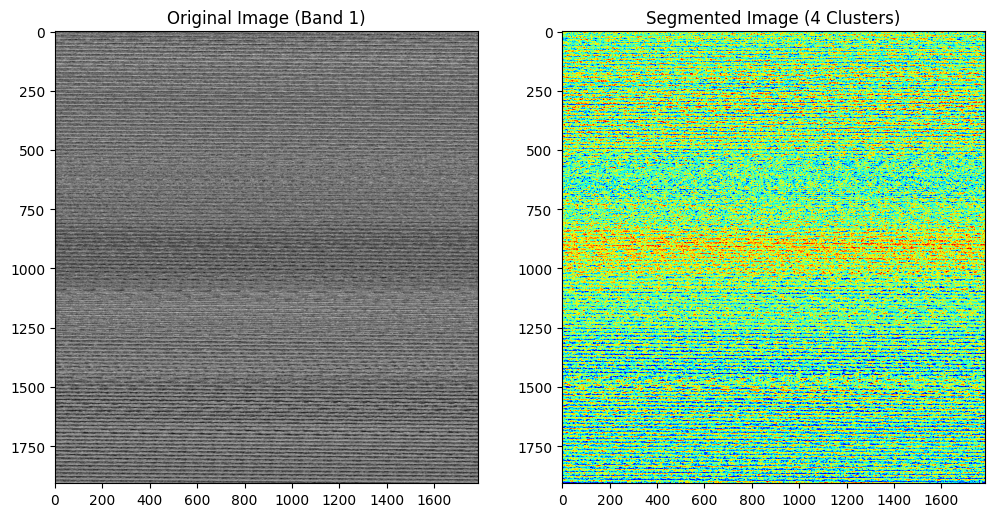

In [15]:
# মূল ছবি এবং সেগমেন্টেড ছবি পাশাপাশি দেখানো
plt.figure(figsize=(12, 6))

# ২D satImg থেকে ১ম ব্যান্ডের ডেটা নিয়ে সেটিকে আবার ছবির আকারে (1907 × 1784) রিসেপ করা
original_band1 = satImg[:, 0].reshape(1907, 1784)

# যেকোনো একটি নির্দিষ্ট ব্যান্ড দেখানোর জন্য (যেমন: ১ম ব্যান্ড)
plt.subplot(1, 2, 1)
plt.title("Original Image (Band 1)")
plt.imshow(original_band1, cmap='gray')

# সেগমেন্টেড বা ক্লাস্টার করা ছবি
plt.subplot(1, 2, 2)
plt.title(f"Segmented Image ({n_clusters} Clusters)")
plt.imshow(segmented_img, cmap='jet')

plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>